# Build SDS archive and segment out event waveform files

## 1. Global parameters and imports


In [2]:
from pathlib import Path
from obspy import read, UTCDateTime, Stream
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from flovopy.seisanio.utils.helpers import write_wavfile

TOP_PATH = Path('/Volumes') / 'tachyon' / 'Artemis2'
#TOP_PATH = Path('/Volumes') / 'Pulwtop' / 'Artemis2'
SDS_DATA_PATH = TOP_PATH / '20_archive' / 'SDS'
WAV_PATH = TOP_PATH / '30_eventwav'

client = EnhancedSDSClient(str(SDS_DATA_PATH))  
launchtime = UTCDateTime('2026-04-01T22:35:12')
duration = 900
pretrigger = 1800
posttrigger = pretrigger
starttime=launchtime - pretrigger
endtime=launchtime + duration + posttrigger

def eventwav_path(launchtime, wav_path=WAV_PATH):
    return wav_path / f'{launchtime.year:04d}' / f'{launchtime.month:02d}'

## 2. USF Nanometrics stations
Already in an SDS archive, so just need to write out event file

In [ ]:
st = client.get_waveforms(network='1R', station='*', location='*', channel='D*', starttime=starttime, endtime=endtime)
write_wavfile(st, WAV_PATH, 'USF', len(st))

# 3. Guralp stations
Files downloaded through web interface

In [ ]:
GURALP_PATH = TOP_PATH / '00_download' / 'Guralp'

for station in ['B07', 'B12']:
    MSEED_PATH = GURALP_PATH / station
    station_files = sorted(list(MSEED_PATH.glob('*.mseed')))
    for station_file in station_files:
        print(f'Processing {station_file}...')
        st_station = read(str(station_file))
        client.write_stream(st_station)

Files downloaded with wget - it creates an sd/ folder

In [ ]:
MSEED_PATH = GURALP_PATH / 'B12' / 'sd'
station_files = sorted(list(MSEED_PATH.glob('*S1Seis*.mseed')))
for station_file in station_files:
    print(f'Processing {station_file}...')
    st_station = read(str(station_file))
    client.write_stream(st_station)

In [ ]:
st = client.get_waveforms(network='DG', station='*', location='*', channel='C*', starttime=starttime, endtime=endtime)
write_wavfile(st, WAV_PATH, 'MSFC', len(st))

# 4. BSU Gem sensors
Already copied all files from microSD cards to a single raw/ directory, and then ran gemconvert.
This created an mseed folder
Now we need to loop over the files in that folder, and write them to an SDS archive.

In [5]:
GEM_MSEED_PATH = TOP_PATH / '10_gemconvert' / 'mseed'
GEM_MSEED_PATH = TOP_PATH / '00_download' / 'gem' / 'mseed'
def fix_gem_trace_id(tr):
    id_dict = {
        '273': '1R.B24LT..HDF',
        '287': '1R.B24RE..HDF',
        '288': '1R.B24..HDF',
        '275': '1R.B24..HDI',
        '296': '1R.B29..HDF',
        '292': '1R.B29..HDI',
        '369': '1R.B12..HDF',
        '290': '1R.B23..HDF',
        '256': '1R.B03..HDF',
        '254': '1R.B03..HDI',
        '246': '1R.B14..HDF',
        '244': '1R.B14..HDI',
        '362': '1R.B01..HDF',
        '251': '1R.B01..HDI',
        '274': '1R.B07.10.HDF',
        '365': '1R.B07..HDF',
        '285': '1R.B20..HDF',
        '361': '1R.B20..HDI',
        '294': '1R.B20.10.HDI',
        '364': '1R.B20W..HDF',
        '366': '1R.B20S..HDF',
        '363': '1R.UNK..HD1' # what is 363, where was it?
    }
    tr.id = id_dict.get(tr.stats.station, tr.id)

for file in sorted(GEM_MSEED_PATH.glob('*.mseed')):
    st = read(str(file))
    for tr in st:
        fix_gem_trace_id(tr)
    print(st)
    print(f"Writing stream for file: {file}")
    client.write_stream(st)    

1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-10T17:45:14.000000Z - 2026-03-10T23:59:59.990000Z | 100.0 Hz, 2248600 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-10T17_45_14..275..HDF.mseed
1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-11T00:00:00.000000Z - 2026-03-11T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-11T00_00_00..275..HDF.mseed
1 Trace(s) in Stream:
1R.UNK..HD1 | 2026-03-11T14:50:43.000000Z - 2026-03-11T23:59:59.990000Z | 100.0 Hz, 3295700 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-11T14_50_43..363..HDF.mseed
1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-12T00:00:00.000000Z - 2026-03-12T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-12T00_00_00..275..HDF.mseed


/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


1 Trace(s) in Stream:
1R.UNK..HD1 | 2026-03-12T00:00:00.000000Z - 2026-03-12T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-12T00_00_00..363..HDF.mseed
1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-13T00:00:00.000000Z - 2026-03-13T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-13T00_00_00..275..HDF.mseed
1 Trace(s) in Stream:
1R.UNK..HD1 | 2026-03-13T00:00:00.000000Z - 2026-03-13T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-13T00_00_00..363..HDF.mseed
1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-14T00:00:00.000000Z - 2026-03-14T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-14T00_00_00..275..HDF.mseed
1 Trace(s) in Stream:
1R.UNK..HD1 | 2026-03-14T00:00:00.000000Z - 2026-03-14

Now let's read the Gem data from the SDS archive - it is the only HD* channel data in there 

In [ ]:
st = client.get_waveforms(network='1R', station='*', location='*', channel='HD*', starttime=starttime, endtime=endtime)
write_wavfile(st, WAV_PATH, 'BSU', len(st))

# 5. Silicon Audio 1-minute files to SDS

In [ ]:
from siliconaudio import merge_miniseed_to_sds
from pathlib import Path

B23_PATH = TOP_PATH / '10_downloads'  / 'SiliconAudio' / 'B23' / 'data'
SDS_B23 = Path('/Volumes') / 'tachyon' / '20260403_DOWNLOAD' / 'B23' / 'dayfiles'

written = merge_miniseed_to_sds(
    input_root=B23_PATH,
    sds_root=SDS_DATA_PATH,
    pattern="*.ms",
    write_mode="merge",
    preprocess=False,
    verbose=True,
)


We want to compute 1-s VSAM (and ISAM or PSAM) and then use the peak RMS, and convert it to SPL
Then plot SPL versus distance

We also want to plot spectrograms

# 6. SmartSolo miniseed files to SDS
DLD files are copied off the SmartSolo internal cards using the SoloLite software.
Then these are converted to 1 miniseed file per channel per day.
Format is serial number, day number, YYYY, MM, DD, HH, MM, SS, 000, N/E/Z, miniseed, all separated by '.'
We need a translation table.



In [10]:
#SMARTSOLO_MSEED_PATH = TOP_PATH / '10_gemconvert' / 'mseed'
SMARTSOLO_MSEED_PATH = TOP_PATH.parent / 'SOLODATA' / 'prospect_ksc' / 'artemis2' / 'ten_stations'

def fix_smartsolo_trace_id(tr):
    chan = tr.stats.channel
    id_dict = {
        '453013783': '1R.B14..DH',
        '453013396': '1R.B01..DH',
        '453014357': '1R.B03..DH',
        '453014233': '1R.B12..DH',
        '453013322': '1R.B07..DH',
        '453012536': '1R.B24..DH',
        '453012683': '1R.B23..DH',  
        '453005764': '1R.B29..DH',
        '453013851': '1R.B20W..DH',
        '453019414': '1R.B20..DH',
        '453020406': '1R.B20S..DH',           
    }
    tr.id = id_dict.get('4530' + tr.stats.station, tr.id)
    tr.stats.channel = chan

files_not_read = []
files_not_fixed = []
files_not_written = []
for file in sorted(SMARTSOLO_MSEED_PATH.glob('*.miniseed')):
    print(file.name)
    try:
        st = read(str(file), header_only=True)
    except:
        files_not_read.append(file.name)
    for tr in st:
        fix_smartsolo_trace_id(tr)
        if tr.stats.network != '1R':
            files_not_fixed.append(file.name)
    print(st)
    print(f"Writing stream for file: {file}")
    try:
        client.write_stream(st)    
    except:
        files_not_written.append(file.name)

print(f'Files not read {files_not_read}')
print(f'Files not fixed {files_not_fixed}')
print(f'Files not written {files_not_written}')


453012536.0001.2026.03.10.17.51.54.000.E.miniseed
1 Trace(s) in Stream:
1R.B24..DPE | 2026-03-10T17:51:54.000000Z - 2026-03-11T00:00:00.000000Z | 500.0 Hz, 11043001 samples
Writing stream for file: /Volumes/tachyon/SOLODATA/prospect_ksc/artemis2/ten_stations/453012536.0001.2026.03.10.17.51.54.000.E.miniseed
453012536.0001.2026.03.10.17.51.54.000.N.miniseed
1 Trace(s) in Stream:
1R.B24..DPN | 2026-03-10T17:51:54.000000Z - 2026-03-11T00:00:00.000000Z | 500.0 Hz, 11043001 samples
Writing stream for file: /Volumes/tachyon/SOLODATA/prospect_ksc/artemis2/ten_stations/453012536.0001.2026.03.10.17.51.54.000.N.miniseed
453012536.0001.2026.03.10.17.51.54.000.Z.miniseed
1 Trace(s) in Stream:
1R.B24..DPZ | 2026-03-10T17:51:54.000000Z - 2026-03-11T00:00:00.000000Z | 500.0 Hz, 11043001 samples
Writing stream for file: /Volumes/tachyon/SOLODATA/prospect_ksc/artemis2/ten_stations/453012536.0001.2026.03.10.17.51.54.000.Z.miniseed
453012536.0002.2026.03.11.00.00.00.000.E.miniseed
1 Trace(s) in Stream:
1

In [11]:
st = client.get_waveforms(network='1R', station='*', location='*', channel='DP*', starttime=starttime, endtime=endtime)
write_wavfile(st, WAV_PATH, 'SmartSolo', len(st))

'/Volumes/tachyon/Artemis2/30_eventwav/2026/04/2026-04-01-2205-12M.SmartSolo_030'

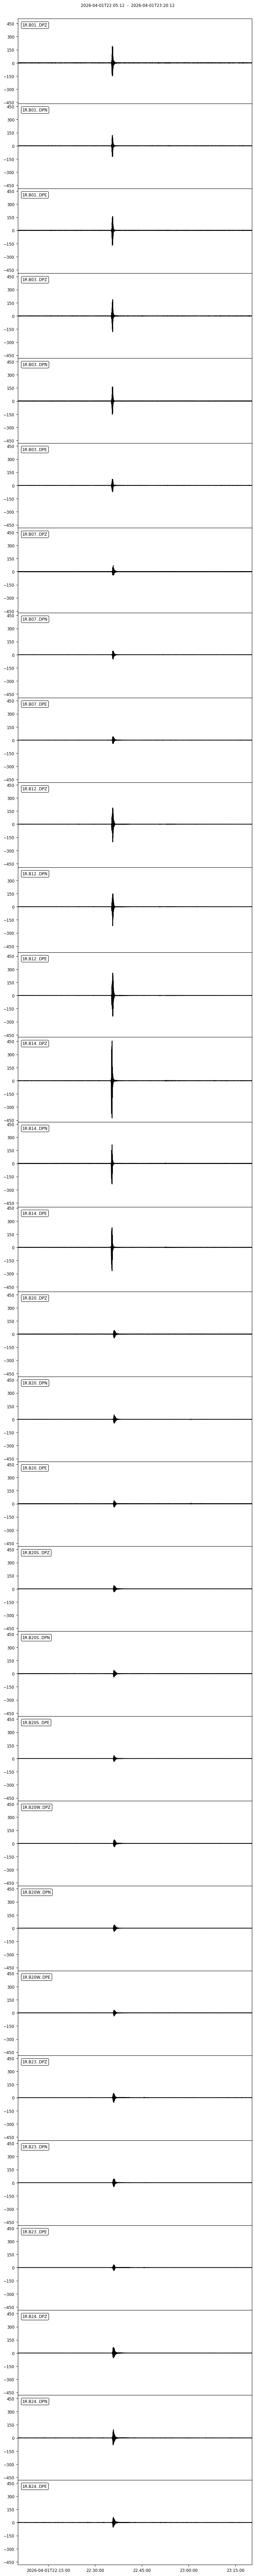

In [14]:
st.plot(equal_scale=True);